Importing dataset from kaggle

In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_ab4ecf7852d742bbf6277337468b55c5'

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d fratzcan/usa-house-prices

Dataset URL: https://www.kaggle.com/datasets/fratzcan/usa-house-prices
License(s): apache-2.0
usa-house-prices.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

with zipfile.ZipFile("usa-house-prices.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [5]:
import pandas as pd
hp = pd.read_csv("data/USA Housing Dataset.csv")

Dataset is ready for veiwing

In [6]:
hp.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


Preprocessing

In [7]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4140 non-null   object 
 1   price          4140 non-null   float64
 2   bedrooms       4140 non-null   float64
 3   bathrooms      4140 non-null   float64
 4   sqft_living    4140 non-null   int64  
 5   sqft_lot       4140 non-null   int64  
 6   floors         4140 non-null   float64
 7   waterfront     4140 non-null   int64  
 8   view           4140 non-null   int64  
 9   condition      4140 non-null   int64  
 10  sqft_above     4140 non-null   int64  
 11  sqft_basement  4140 non-null   int64  
 12  yr_built       4140 non-null   int64  
 13  yr_renovated   4140 non-null   int64  
 14  street         4140 non-null   object 
 15  city           4140 non-null   object 
 16  statezip       4140 non-null   object 
 17  country        4140 non-null   object 
dtypes: float

In [8]:
#date is not going to be beneficial for interpretation but will make modlling 
del hp['date']

In [9]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4140 non-null   float64
 1   bedrooms       4140 non-null   float64
 2   bathrooms      4140 non-null   float64
 3   sqft_living    4140 non-null   int64  
 4   sqft_lot       4140 non-null   int64  
 5   floors         4140 non-null   float64
 6   waterfront     4140 non-null   int64  
 7   view           4140 non-null   int64  
 8   condition      4140 non-null   int64  
 9   sqft_above     4140 non-null   int64  
 10  sqft_basement  4140 non-null   int64  
 11  yr_built       4140 non-null   int64  
 12  yr_renovated   4140 non-null   int64  
 13  street         4140 non-null   object 
 14  city           4140 non-null   object 
 15  statezip       4140 non-null   object 
 16  country        4140 non-null   object 
dtypes: float64(4), int64(9), object(4)
memory usage: 550

In [10]:
hp['country'].nunique()

1

In [11]:
#Country is not gonna have effect so we remove it
del hp['country']

In [12]:
hp.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.140000e+03,4140.000000,4140.000000,4140.000000,4.140000e+03,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000,4140.000000
mean,5.530629e+05,3.400483,2.163043,2143.638889,1.469764e+04,1.514130,0.007488,0.246618,3.452415,1831.351449,312.287440,1970.814010,808.368357
std,5.836865e+05,0.903939,0.784733,957.481621,3.587684e+04,0.534941,0.086219,0.790619,0.678533,861.382947,464.349222,29.807941,979.380535
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.200000e+05,3.000000,1.750000,1470.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.600000e+05,3.000000,2.250000,1980.000000,7.676000e+03,1.500000,0.000000,0.000000,3.000000,1600.000000,0.000000,1976.000000,0.000000
75%,6.591250e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2310.000000,602.500000,1997.000000,1999.000000
max,2.659000e+07,8.000000,6.750000,10040.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,4820.000000,2014.000000,2014.000000


In [13]:
#Removing entries with price of zero
hp=hp[hp['price']>0]

In [14]:
hp['price'].describe()

count    4.091000e+03
mean     5.596872e+05
std      5.840060e+05
min      7.800000e+03
25%      3.250938e+05
50%      4.646000e+05
75%      6.600000e+05
max      2.659000e+07
Name: price, dtype: float64

In [15]:
#statezip and street will also have no purpose
del hp['statezip']
del hp['street']

In [16]:
import seaborn as sns

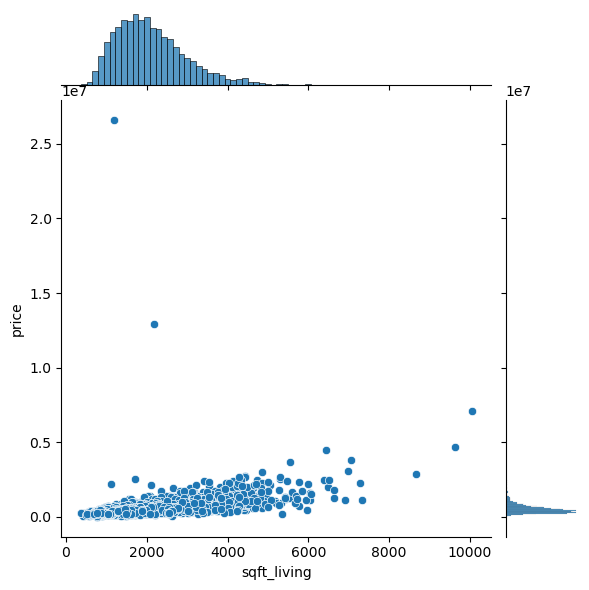

In [17]:
sns.jointplot(data=hp, x='sqft_living', y='price')

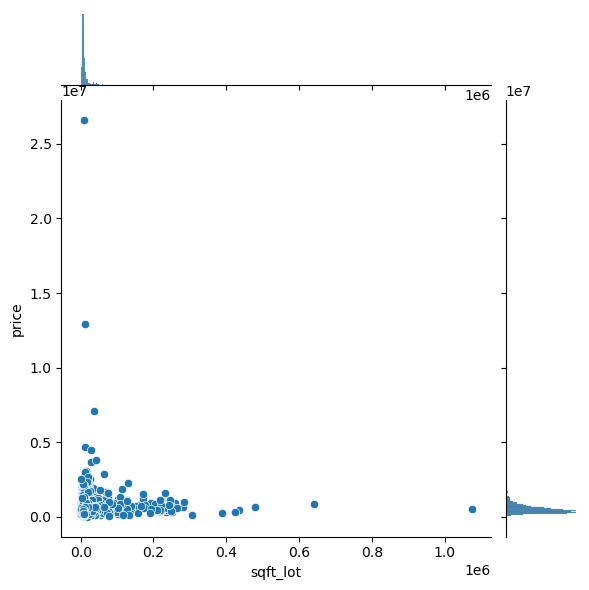

In [18]:
sns.jointplot(data=hp, x='sqft_lot', y= 'price')

In [19]:
#sqft_lot seems to be highly skewed and showing no relationship so we transform it
import numpy as np
hp['sqft_lot']=np.log(hp['sqft_lot'])

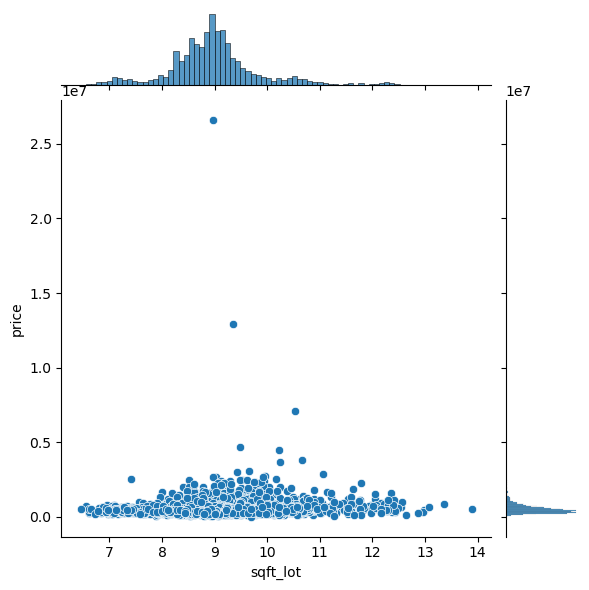

In [20]:
sns.jointplot(data=hp, x='sqft_lot', y='price')

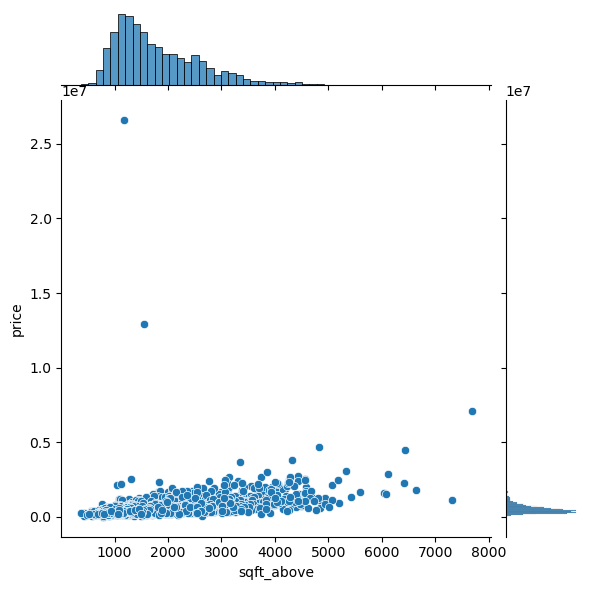

In [21]:
sns.jointplot(data=hp, x='sqft_above', y='price')

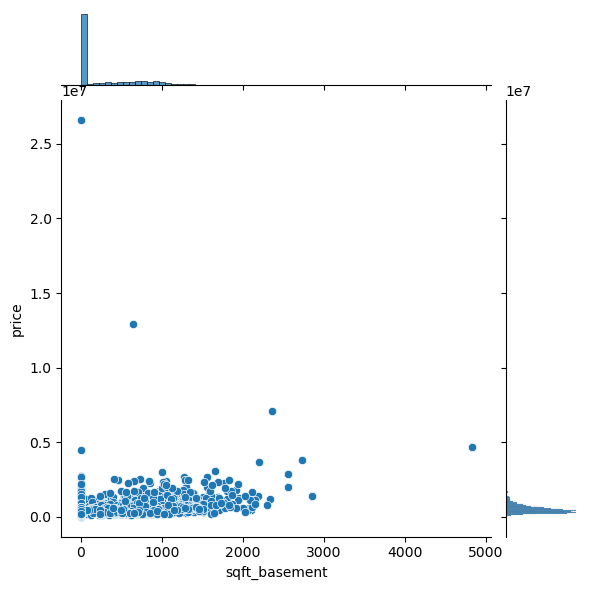

In [22]:
sns.jointplot(data=hp, x='sqft_basement', y='price')

In [23]:
hp['sqft_basement']=np.log(1+hp['sqft_basement'])


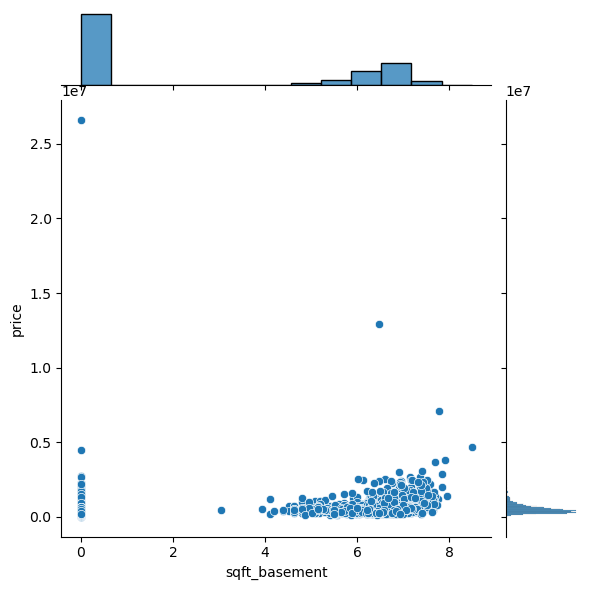

In [24]:
sns.jointplot(data=hp, x='sqft_basement', y='price')

sqft_lot and sqft_basement looks better now,  sqft_above and sqft_living always showed a linear relationship

In [25]:
#Correlation matrix for continuous variables
hp.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.199341,0.332749,0.434733,0.102320,0.144451,0.146449,0.232152,0.034530,0.369140,0.128027,0.027002,-0.028544
bedrooms,0.199341,1.000000,0.544332,0.591313,0.218921,0.177069,-0.003362,0.109797,0.014023,0.479034,0.214548,0.152635,-0.070862
bathrooms,0.332749,0.544332,1.000000,0.755917,0.125132,0.490962,0.066309,0.203531,-0.123941,0.684603,0.190012,0.471803,-0.223955
sqft_living,0.434733,0.591313,0.755917,1.000000,0.371018,0.343648,0.115828,0.306142,-0.069116,0.873952,0.250573,0.293340,-0.123313
sqft_lot,0.102320,0.218921,0.125132,0.371018,1.000000,-0.210915,0.079277,0.113039,0.063013,0.365839,-0.028143,0.013659,0.041302
floors,0.144451,0.177069,0.490962,0.343648,-0.210915,1.000000,0.014403,0.031451,-0.273819,0.524130,-0.284341,0.469286,-0.236658
waterfront,0.146449,-0.003362,0.066309,0.115828,0.079277,0.014403,1.000000,0.344729,0.010552,0.074205,0.044798,-0.041545,0.022193
view,0.232152,0.109797,0.203531,0.306142,0.113039,0.031451,0.344729,1.000000,0.063939,0.167361,0.230069,-0.069987,0.032162
condition,0.034530,0.014023,-0.123941,-0.069116,0.063013,-0.273819,0.010552,0.063939,1.000000,-0.181879,0.183096,-0.399502,-0.185395
sqft_above,0.369140,0.479034,0.684603,0.873952,0.365839,0.524130,0.074205,0.167361,-0.181879,1.000000,-0.196600,0.414372,-0.164385


In [26]:
#sqft_living is highly correlating with sqft_above(87%), so I remoove one
del hp['sqft_above']

Defining variables

In [27]:
x= hp.drop('price', axis=1)

In [28]:
x=pd.get_dummies(x, drop_first=True)

In [29]:
y= hp['price']

Test_train_split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,train_size=0.8, random_state= 0)

Linear regression model Training

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
Lnr = LinearRegression()

In [34]:
Lnr.fit(x_train, y_train)

LinearRegression()

Model perfomance

In [35]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
r2_score(y_test, Lnr.predict(x_test))

0.6314260328068713

The model explains 63% of the variation in house prices

In [36]:
np.sqrt(mean_squared_error(y_test,Lnr.predict(x_test)))
        

np.float64(195711.65465413558)

195711.65465413558 is too large. Extreme outliers of price are definitely affecting the model.
They were initially not capped because price of house can always be extreme if the house is luxurious.

In [37]:
#Capping price
np.percentile(hp['price'],[99])

array([2030800.])

In [38]:
np.percentile(hp['price'],[99])[0]

np.float64(2030799.9999999965)

In [39]:
uplim=np.percentile(hp['price'],[99])[0]

In [40]:
hp[hp['price']>uplim].head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,yr_built,yr_renovated,city
2,2238888.0,5.0,6.50,7270,11.775420,2.0,0,0,3,6.746412,2010,0,Issaquah
121,2555000.0,4.0,2.50,5300,10.173934,2.0,1,2,2,6.594413,1923,0,Seattle
285,2100000.0,4.0,1.75,3550,9.896715,2.0,0,0,3,0.000000,1962,2002,Medina
672,2700000.0,5.0,4.75,5305,9.036106,2.0,0,2,3,7.353082,2005,0,Kirkland
749,2150000.0,4.0,5.50,5060,9.241839,2.0,0,0,3,0.000000,2008,0,Bellevue


In [41]:
#Values of price where price is greater than 3 x upper Limit
#These are the extreme outliers ruining the model
hp['price'][hp['price']>3*uplim]

1826     7062500.0
3886    12899000.0
3890    26590000.0
Name: price, dtype: float64

In [42]:
hp['price'][hp['price']>3*uplim]=3*uplim

C:\Users\tebog\AppData\Local\Temp\ipykernel_14436\822875721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hp['price'][hp['price']>3*uplim]=3*uplim


Redifining variables

In [43]:
hp = pd.get_dummies(hp, columns=['city'], drop_first=True)

In [44]:
x = hp.drop('price', axis=1)

In [45]:
y= hp['price']

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,train_size=0.8, random_state= 0)

In [47]:
print(x_train.shape, y_test.shape, y_train.shape, y_test.shape)

(3272, 53) (819,) (3272,) (819,)


Retraining model

In [48]:
Lnr2 = LinearRegression()

In [49]:
Lnr2.fit(x_train, y_train)

LinearRegression()

Model perfomance

In [50]:
r2_score(y_test, Lnr2.predict(x_test))

0.6492578015160694

In [51]:
np.sqrt(mean_squared_error(y_test,Lnr2.predict(x_test)))
        

np.float64(190918.65670240755)

Want to validate significance of coefficients, so I'm rebuilding the model using stats models

In [52]:
import statsmodels.api as sn

In [53]:
#Resultant columns of the get_dummmies are booleans, statsmodels might read them as strings since its very strict
x_train = x_train.astype(float)
x_test = x_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [54]:
x_train_sm= sn.add_constant(x_train)
x_test_sm=sn.add_constant(x_test)

In [55]:
Lnr3 = sn.OLS(y_train,x_train_sm).fit()

In [56]:
Lnr3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     101.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:32:33   Log-Likelihood:                -45256.
No. Observations:                3272   AIC:                         9.062e+04
Df Residuals:                    3218   BIC:                         9.095e+04
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1.966e+06   5.47e+05      3.593      0.000    8.93e+05    3.04e+06
bedrooms                -4.417e+04   6227.716     -7.093      0.000   -5.64e+04    -3.2e+04
bathrooms                5.195e+04   1.01e+04      5.160      0.000    3.22e+04    7.17e+04
sqft_living               251.7861      8.809     28.583      0.000     234.514     269.058
sqft_lot                -1.572e+04   6964.417     -2.257      0.024   -2.94e+04   -2060.405
floors                  -5635.8158   1.24e+04     -0.456      0.648   -2.99e+04    1.86e+04
waterfront               5.407e+05   5.53e+04      9.775      0.000    4.32e+05    6.49e+05
view                      5.23e+04   6316.669      8.280      0.000    3.99e+04    6.47e+04
condition                3.051e+04   7823.485      3.899      0.000    1.52e+04    4.58e+04
sqft_basement            -1.04e+04   1777.057     -5.853      0.000   -1.39e+04   -6916.161
yr_built                -1044.2152    235.837     -4.428      0.000   -1506.621    -581.809
yr_renovated                3.4187      5.167      0.662      0.508      -6.711      13.549
city_Auburn             -1.008e+04   2.49e+05     -0.040      0.968   -4.98e+05    4.78e+05
city_Beaux Arts Village  5.604e+05   3.51e+05      1.596      0.110   -1.28e+05    1.25e+06
city_Bellevue            3.737e+05   2.49e+05      1.502      0.133   -1.14e+05    8.61e+05
city_Black Diamond       1.354e+05   2.77e+05      0.488      0.626   -4.09e+05    6.79e+05
city_Bothell             1.155e+05   2.53e+05      0.456      0.648   -3.81e+05    6.11e+05
city_Burien              4.213e+04   2.51e+05      0.168      0.867   -4.49e+05    5.34e+05
city_Carnation           8.523e+04   2.59e+05      0.329      0.742   -4.23e+05    5.93e+05
city_Clyde Hill          1.072e+06   2.68e+05      3.996      0.000    5.46e+05     1.6e+06
city_Covington           7.058e+04   2.52e+05      0.280      0.780   -4.24e+05    5.65e+05
city_Des Moines         -1.544e+04   2.51e+05     -0.062      0.951   -5.07e+05    4.77e+05
city_Duvall              8.149e+04   2.52e+05      0.324      0.746   -4.12e+05    5.75e+05
city_Enumclaw            1.552e+04   2.54e+05      0.061      0.951   -4.83e+05    5.14e+05
city_Fall City           2.158e+05   2.62e+05      0.824      0.410   -2.98e+05    7.29e+05
city_Federal Way        -3.278e+04   2.49e+05     -0.131      0.895   -5.22e+05    4.56e+05
city_Issaquah            1.873e+05   2.49e+05      0.752      0.452   -3.01e+05    6.76e+05
city_Kenmore             1.457e+05   2.51e+05      0.580      0.562   -3.47e+05    6.38e+05
city_Kent                4.558e+04   2.49e+05      0.183      0.855   -4.43e+05    5.34e+05
city_Kirkland            2.745e+05   2.49e+05      1.102      0.270   -2.14e+05    7.63e+05
city_Lake Forest Park      1.3e+05   2.53e+05  

Dropping insignificant variables and retraining model

In [59]:
x2 = hp.drop(columns = ['price', 'yr_renovated']) 

The variable 'year_renovated' was found to be statistically insignificant and was removed from the model.  
This is due to a large number of properties with no renovation history, reducing its explanatory power.

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x2, y, test_size = 0.2,train_size=0.8, random_state= 0)

In [61]:
x_train = x_train.astype(float)
x_test = x_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [66]:
x_train_sm2= sn.add_constant(x_train)
x_test_sm2= sn.add_constant(x_test)

In [67]:
Lnr4 = sn.OLS(y_train,x_train_sm2).fit()

In [64]:
Lnr4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     103.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:40:00   Log-Likelihood:                -45256.
No. Observations:                3272   AIC:                         9.062e+04
Df Residuals:                    3219   BIC:                         9.094e+04
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2.053e+06   5.31e+05      3.866      0.000    1.01e+06    3.09e+06
bedrooms                -4.404e+04   6224.057     -7.076      0.000   -5.62e+04   -3.18e+04
bathrooms                5.171e+04   1.01e+04      5.140      0.000     3.2e+04    7.14e+04
sqft_living               251.7181      8.808     28.580      0.000     234.449     268.987
sqft_lot                -1.547e+04   6954.289     -2.225      0.026   -2.91e+04   -1839.384
floors                  -6270.7130   1.23e+04     -0.509      0.611   -3.04e+04    1.79e+04
waterfront               5.407e+05   5.53e+04      9.777      0.000    4.32e+05    6.49e+05
view                     5.242e+04   6313.783      8.302      0.000       4e+04    6.48e+04
condition                2.854e+04   7235.291      3.944      0.000    1.44e+04    4.27e+04
sqft_basement           -1.038e+04   1776.711     -5.844      0.000   -1.39e+04   -6899.625
yr_built                -1085.6149    227.367     -4.775      0.000   -1531.413    -639.817
city_Auburn             -7215.9590   2.49e+05     -0.029      0.977   -4.95e+05    4.81e+05
city_Beaux Arts Village   5.67e+05   3.51e+05      1.616      0.106   -1.21e+05    1.25e+06
city_Bellevue            3.769e+05   2.49e+05      1.516      0.130   -1.11e+05    8.64e+05
city_Black Diamond       1.405e+05   2.77e+05      0.507      0.613   -4.03e+05    6.84e+05
city_Bothell             1.186e+05   2.53e+05      0.469      0.639   -3.77e+05    6.14e+05
city_Burien              4.612e+04   2.51e+05      0.184      0.854   -4.45e+05    5.37e+05
city_Carnation           8.534e+04   2.59e+05      0.329      0.742   -4.23e+05    5.94e+05
city_Clyde Hill          1.077e+06   2.68e+05      4.017      0.000    5.51e+05     1.6e+06
city_Covington           7.377e+04   2.52e+05      0.293      0.770    -4.2e+05    5.68e+05
city_Des Moines          -1.19e+04   2.51e+05     -0.047      0.962   -5.04e+05     4.8e+05
city_Duvall              8.338e+04   2.52e+05      0.331      0.741    -4.1e+05    5.77e+05
city_Enumclaw            1.681e+04   2.54e+05      0.066      0.947   -4.82e+05    5.15e+05
city_Fall City           2.177e+05   2.62e+05      0.832      0.406   -2.96e+05    7.31e+05
city_Federal Way        -2.986e+04   2.49e+05     -0.120      0.905   -5.19e+05    4.59e+05
city_Issaquah            1.898e+05   2.49e+05      0.762      0.446   -2.98e+05    6.78e+05
city_Kenmore             1.484e+05   2.51e+05      0.591      0.555   -3.44e+05    6.41e+05
city_Kent                4.801e+04   2.49e+05      0.193      0.847    -4.4e+05    5.36e+05
city_Kirkland            2.775e+05   2.49e+05      1.115      0.265   -2.11e+05    7.66e+05
city_Lake Forest Park     1.34e+05   2.53e+05      0.529      0.597   -3.62e+05     6.3e+05
city_Maple Valley        2.389e+04    2.5e+05  

In [70]:
Lnr4.predict(x_test_sm2)

3242    809824.030475
2709    436794.074130
3610    222072.567113
3639    560234.707231
3921    963418.552352
            ...      
1347    268574.890279
2588    247776.523120
1115    592476.069858
720     162807.699004
2756    721198.596979
Length: 819, dtype: float64

In [72]:
print(np.sqrt(mean_squared_error(y_test,Lnr4.predict(x_test_sm2))))

191009.36342842376


### Feature Selection
The variable 'year_renovated' was removed due to  insignificance of coefficients.  
Model performance remained unchanged after its removal, while MSE increased from 190 918, indicating that it still helping predictions.

In [75]:
x3 = hp.drop(['price', 'floors'], axis=1)

In [76]:
x_train, x_test, y_train, y_test = train_test_split(x3, y, test_size = 0.2,train_size=0.8, random_state= 0)

In [77]:
x_train = x_train.astype(float)
x_test = x_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

In [78]:
x_train_sm3= sn.add_constant(x_train)
x_test_sm3= sn.add_constant(x_test)

In [79]:
Lnr5 = sn.OLS(y_train,x_train_sm3).fit()

In [80]:
Lnr5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     103.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:08:46   Log-Likelihood:                -45256.
No. Observations:                3272   AIC:                         9.062e+04
Df Residuals:                    3219   BIC:                         9.094e+04
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    2.001e+06   5.42e+05      3.691      0.000    9.38e+05    3.06e+06
bedrooms                -4.417e+04   6226.947     -7.093      0.000   -5.64e+04    -3.2e+04
bathrooms                5.087e+04   9786.057      5.199      0.000    3.17e+04    7.01e+04
sqft_living               250.8324      8.556     29.316      0.000     234.056     267.609
sqft_lot                -1.481e+04   6674.886     -2.219      0.027   -2.79e+04   -1722.910
waterfront               5.405e+05   5.53e+04      9.774      0.000    4.32e+05    6.49e+05
view                     5.228e+04   6315.685      8.278      0.000    3.99e+04    6.47e+04
condition                3.075e+04   7804.292      3.940      0.000    1.54e+04    4.61e+04
sqft_basement           -1.001e+04   1559.938     -6.418      0.000   -1.31e+04   -6953.767
yr_built                -1066.8947    230.508     -4.628      0.000   -1518.852    -614.938
yr_renovated                3.6017      5.150      0.699      0.484      -6.497      13.700
city_Auburn              -1.33e+04   2.49e+05     -0.053      0.957   -5.01e+05    4.75e+05
city_Beaux Arts Village  5.559e+05   3.51e+05      1.584      0.113   -1.32e+05    1.24e+06
city_Bellevue            3.705e+05   2.49e+05      1.490      0.136   -1.17e+05    8.58e+05
city_Black Diamond       1.316e+05   2.77e+05      0.475      0.635   -4.12e+05    6.75e+05
city_Bothell             1.123e+05   2.53e+05      0.444      0.657   -3.83e+05    6.08e+05
city_Burien              3.834e+04    2.5e+05      0.153      0.878   -4.53e+05    5.29e+05
city_Carnation            8.08e+04   2.59e+05      0.312      0.755   -4.27e+05    5.89e+05
city_Clyde Hill          1.071e+06   2.68e+05      3.992      0.000    5.45e+05     1.6e+06
city_Covington           6.775e+04   2.52e+05      0.269      0.788   -4.26e+05    5.62e+05
city_Des Moines         -1.892e+04   2.51e+05     -0.075      0.940   -5.11e+05    4.73e+05
city_Duvall              7.695e+04   2.52e+05      0.306      0.760   -4.16e+05     5.7e+05
city_Enumclaw            1.165e+04   2.54e+05      0.046      0.963   -4.87e+05     5.1e+05
city_Fall City           2.117e+05   2.62e+05      0.809      0.418   -3.01e+05    7.25e+05
city_Federal Way        -3.597e+04   2.49e+05     -0.144      0.885   -5.24e+05    4.53e+05
city_Issaquah             1.83e+05   2.49e+05      0.735      0.462   -3.05e+05    6.71e+05
city_Kenmore             1.419e+05   2.51e+05      0.566      0.572    -3.5e+05    6.34e+05
city_Kent                4.204e+04   2.49e+05      0.169      0.866   -4.46e+05     5.3e+05
city_Kirkland            2.715e+05   2.49e+05      1.091      0.275   -2.17e+05     7.6e+05
city_Lake Forest Park    1.268e+05   2.53e+05      0.501      0.616    -3.7e+05    6.23e+05
city_Maple Valley        1.767e+04    2.5e+05  

In [81]:
print(np.sqrt(mean_squared_error(y_test,Lnr5.predict(x_test_sm3))))

np.float64(190858.04169707047)

## Conclusion
After including yr_renovated again and removing floors, model accuracy remained the same while MSE became the lowest, pin-pointing the variable floors as the culprit (insignificant and not helping predictions). Lnr5 will be my final model as I research other ways to decrease this large MSE